
Lorentzian Parameters (Frequency form)
--------------------------------------
A      = 0.016
f0     = 5.996 Hz
gamma  = 0.207 Hz
C      = 0.009

Lorentzian Parameters (Angular frequency form)
----------------------------------------------
A       = 0.016
omega0  = 37.675 rad/s
gamma   = 1.299 rad/s
C       = 0.009


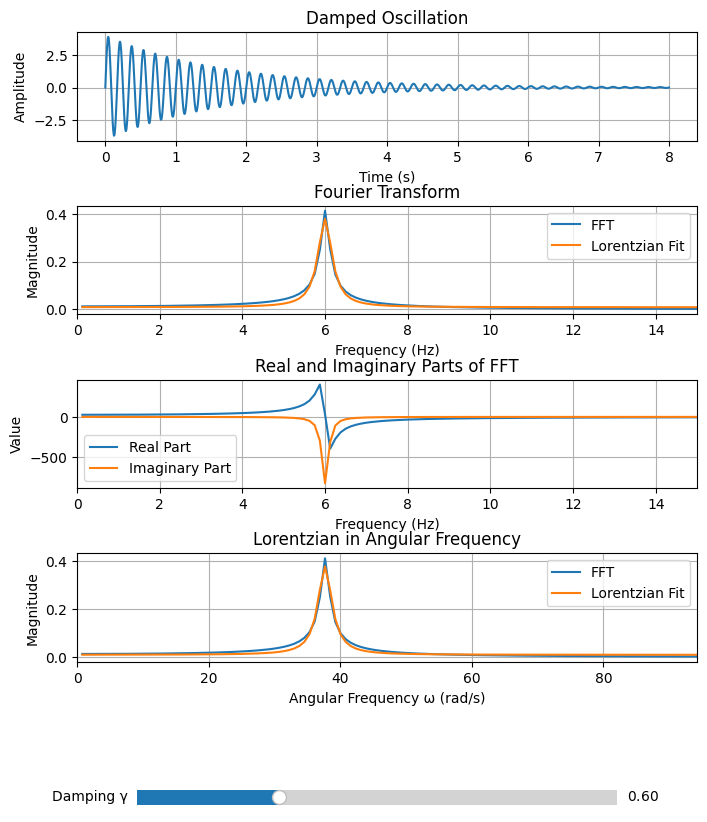

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.widgets import Slider

# Time
T = 8
N = 2000
t = np.linspace(0, T, N)

# Oscillation parameters
A = 4
f0 = 6
omega = 2*np.pi*f0

# Lorentzian function
def lorentzian(f, A, f0, gamma, C):
    return A / ((f - f0)**2 + gamma**2) + C

# initial damping
gamma_init = 0.6

# plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(8,10))
plt.subplots_adjust(bottom=0.25, hspace=0.6)

def compute_and_plot(gamma):

    ax1.clear()
    ax2.clear()
    ax3.clear()
    ax4.clear()

    # damped oscillation
    x = A*np.exp(-gamma*t)*np.sin(omega*t)

    # Fourier Transform
    X = np.fft.fft(x)
    freq = np.fft.fftfreq(len(t), t[1]-t[0])

    # keep positive frequencies
    mask = freq > 0
    freq_pos = freq[mask]
    omega_pos = 2*np.pi*freq_pos

    # normalize magnitude
    mag = np.abs(X[mask]) / N

    real_part = np.real(X[mask])
    imag_part = np.imag(X[mask])

    # peak index
    peak_index = np.argmax(mag)

    # fitting range
    fit_range = 100
    start = max(0, peak_index - fit_range)
    end = min(len(freq_pos), peak_index + fit_range)

    f_fit = freq_pos[start:end]
    mag_fit = mag[start:end]

    omega_fit = 2*np.pi*f_fit

    # initial guess
    p0 = [max(mag_fit), f0, 0.5, min(mag_fit)]

    # Lorentzian fit
    popt, _ = curve_fit(lorentzian, f_fit, mag_fit, p0=p0)

    A_l, f0_l, gamma_l, C_l = popt

    # convert to angular frequency
    omega0 = 2*np.pi*f0_l
    gamma_omega = 2*np.pi*gamma_l

    print("\nLorentzian Parameters (Frequency form)")
    print("--------------------------------------")
    print(f"A      = {A_l:.3f}")
    print(f"f0     = {f0_l:.3f} Hz")
    print(f"gamma  = {gamma_l:.3f} Hz")
    print(f"C      = {C_l:.3f}")

    print("\nLorentzian Parameters (Angular frequency form)")
    print("----------------------------------------------")
    print(f"A       = {A_l:.3f}")
    print(f"omega0  = {omega0:.3f} rad/s")
    print(f"gamma   = {gamma_omega:.3f} rad/s")
    print(f"C       = {C_l:.3f}")

    # time plot
    ax1.plot(t, x)
    ax1.set_title("Damped Oscillation")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.grid()

    # FFT plot
    ax2.plot(freq_pos, mag, label="FFT")
    ax2.plot(f_fit, lorentzian(f_fit,*popt), label="Lorentzian Fit")

    ax2.set_xlim(0,15)
    ax2.set_title("Fourier Transform")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Magnitude")
    ax2.legend()
    ax2.grid()

    # real & imaginary
    ax3.plot(freq_pos, real_part, label="Real Part")
    ax3.plot(freq_pos, imag_part, label="Imaginary Part")

    ax3.set_xlim(0,15)
    ax3.set_title("Real and Imaginary Parts of FFT")
    ax3.set_xlabel("Frequency (Hz)")
    ax3.set_ylabel("Value")
    ax3.legend()
    ax3.grid()

    # omega plot
    ax4.plot(omega_pos, mag, label="FFT")
    ax4.plot(omega_fit, lorentzian(f_fit,*popt), label="Lorentzian Fit")

    ax4.set_xlim(0,2*np.pi*15)
    ax4.set_title("Lorentzian in Angular Frequency")
    ax4.set_xlabel("Angular Frequency ω (rad/s)")
    ax4.set_ylabel("Magnitude")
    ax4.legend()
    ax4.grid()

    fig.canvas.draw_idle()

# initial plot
compute_and_plot(gamma_init)

# slider
ax_slider = plt.axes([0.2,0.1,0.6,0.03])
slider = Slider(ax_slider, "Damping γ", 0.01, 2, valinit=gamma_init)

def update(val):
    compute_and_plot(slider.val)

slider.on_changed(update)

plt.show()